In [1]:
# Homework 11

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

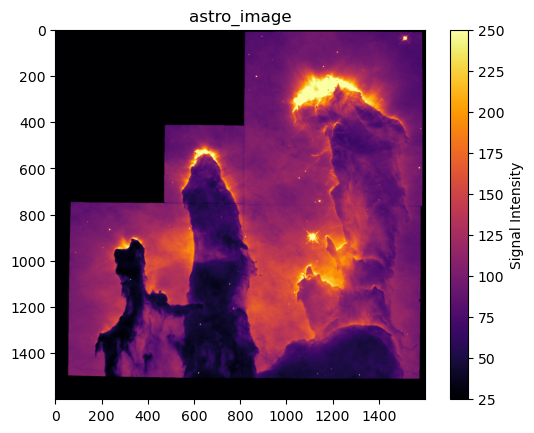

In [3]:
data = np.loadtxt('astro_image.csv')

plt.figure()
plt.imshow(data, cmap='inferno', vmin=25, vmax=250)
plt.colorbar(label='Signal Intensity')
plt.title('astro_image')
plt.show()

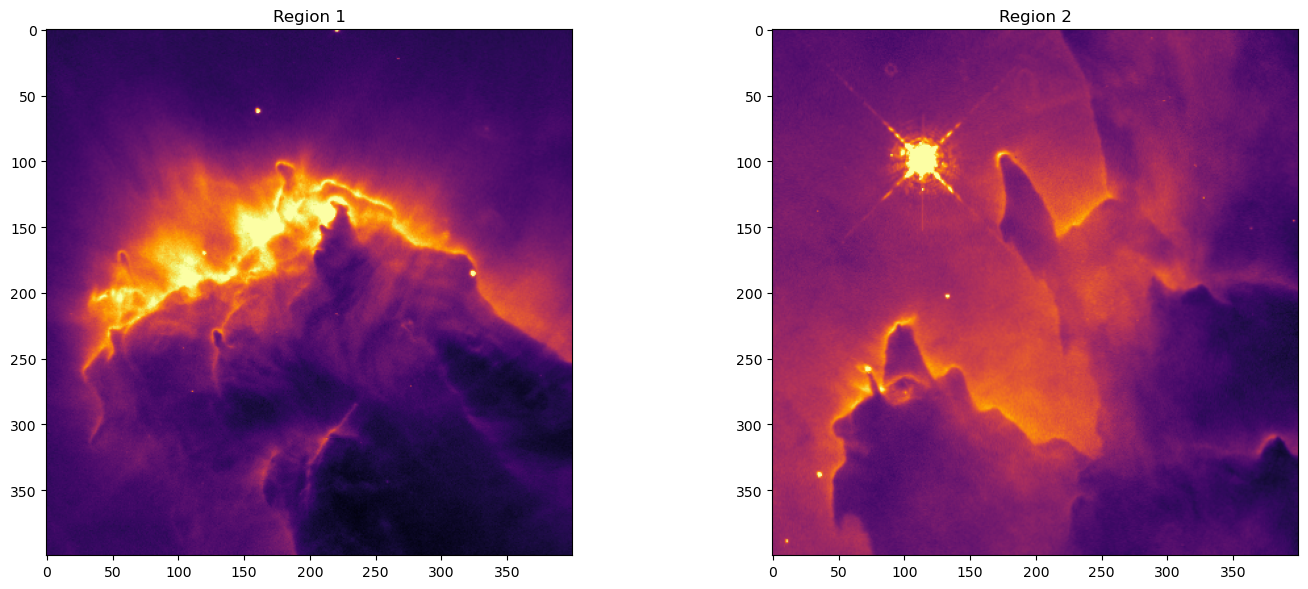

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

region_1 = data[100:500, 1000:1400]
ax1.imshow(region_1, cmap='inferno', vmin=50, vmax=350)
ax1.set_title('Region 1')

region_2 = data[800:1200, 1000:1400]
ax2.imshow(region_2, cmap='inferno', vmin=50, vmax=300)
ax2.set_title('Region 2')

plt.tight_layout()
plt.show()

In [5]:
df = pd.read_csv('ramen-ratings.csv')
df.head()

,Review #,Brand,Variety,Style,Country,Stars,Top Ten
0,2580,New Touch,T's Restaurant Tantanmen,Cup,Japan,3.75,NaN
1,2579,Just Way,Noodles Spicy Hot Sesame Spicy Hot Sesame Guan...,Pack,Taiwan,1,NaN
2,2578,Nissin,Cup Noodles Chicken Vegetable,Cup,USA,2.25,NaN
3,2577,Wei Lih,GGE Ramen Snack Tomato Flavor,Pack,Taiwan,2.75,NaN
4,2576,Ching's Secret,Singapore Curry,Pack,India,3.75,NaN


The names of each column are: Review #, Brand, Variety, Style, Country, Stars, Top Ten

In [6]:
df.columns

Index(['Review #', 'Brand', 'Variety', 'Style', 'Country', 'Stars', 'Top Ten'], dtype='object')

The style of the 27th entry is 'Pack'

In [7]:
df.loc[26, "Style"]

'Pack'

355 Brands

In [8]:
df["Brand"].nunique()

355

df_sorted sorts the ramen data by brand name alphabetically

In [9]:
df_sorted = df.sort_values("Brand")
df_sorted.head()

,Review #,Brand,Variety,Style,Country,Stars,Top Ten
229,2351,1 To 3 Noodles,Chatpat Masala,Pack,India,4,NaN
456,2124,7 Select,Nissin Instant Noodles Tom Yum Seafood Creamy ...,Bowl,Thailand,3.5,NaN
463,2117,7 Select,Nissin Instant Noodles Shrimp Ma Nao Lui Suan ...,Bowl,Thailand,4,NaN
877,1703,7 Select/Nissin,Super Tom Yum Shrimp,Cup,Thailand,3.5,NaN
911,1669,A-One,Mi Ly Instant Noodles Mi Chay Vegetarian Flavor,Cup,Vietnam,1.25,NaN


49 brands of ramen are made in the US

In [10]:
df_usa = df[df["Country"] == "USA"]
df_usa["Brand"].nunique()

49

27 US brands make pack ramen

In [11]:
usa_pack = df[(df["Country"] == "USA") & (df["Style"] == "Pack")]
usa_pack["Brand"].nunique()

27

These brands have been in the top ten: 'MAMA', 'Prima Taste', 'Prima', 'Tseng Noodles', 'Wugudaochang',
       'A-Sha Dry Noodle', 'MyKuali', 'CarJEN', 'Maruchan', 'Mamee',
       'Mama', 'Sapporo Ichiban', 'Nongshim', 'Samyang Foods', 'Paldo',
       'Indomie', 'Koka', 'Mi Sedaap', 'Nissin', 'Myojo', and 'Doll'

In [12]:
top_ten = df[df["Top Ten"].notna()]
top_ten_brands = top_ten["Brand"].unique()
top_ten_brands

array(['MAMA', 'Prima Taste', 'Prima', 'Tseng Noodles', 'Wugudaochang',
       'A-Sha Dry Noodle', 'MyKuali', 'CarJEN', 'Maruchan', 'Mamee',
       'Mama', 'Sapporo Ichiban', 'Nongshim', 'Samyang Foods', 'Paldo',
       'Indomie', 'Koka', 'Mi Sedaap', 'Nissin', 'Myojo', 'Doll'],
      dtype=object)

In [15]:
from astropy.table import Table

tbl = Table.read("global_CCl4_MM.dat", format="ascii")
tbl

CCl4ottoyr,CCl4ottomon,CCl4ottoNHm,CCl4ottoNHsd,CCl4ottoSHm,CCl4ottoSHsd,CCl4ottoGLm,CCl4ottoGLsd
int64,int64,float64,float64,float64,float64,float64,float64
1996,1,nan,nan,nan,nan,nan,nan
1996,2,nan,nan,nan,nan,nan,nan
1996,3,nan,nan,nan,nan,nan,nan
1996,4,105.318,0.197,102.969,0.238,104.144,0.155
1996,5,105.032,0.193,102.754,0.287,103.893,0.174
1996,6,105.327,0.277,103.086,0.273,104.207,0.191
1996,7,105.25,0.171,103.021,0.233,104.136,0.147
1996,8,104.855,0.239,102.817,0.213,103.836,0.161
1996,9,104.909,0.248,102.813,0.441,103.861,0.254


In [16]:
tbl.colnames

['CCl4ottoyr',
 'CCl4ottomon',
 'CCl4ottoNHm',
 'CCl4ottoNHsd',
 'CCl4ottoSHm',
 'CCl4ottoSHsd',
 'CCl4ottoGLm',
 'CCl4ottoGLsd']

In [17]:
df = tbl.to_pandas()

df = df[["CCl4ottoyr", "CCl4ottoGLm", "CCl4ottoGLsd"]]
df.head()


,CCl4ottoyr,CCl4ottoGLm,CCl4ottoGLsd
0,1996,NaN,NaN
1,1996,NaN,NaN
2,1996,NaN,NaN
3,1996,104.144,0.155
4,1996,103.893,0.174


In [18]:
df = df.rename(columns={
    "CCl4ottoyr": "date",
    "CCl4ottoGLm": "global_mean",
    "CCl4ottoGLsd": "global_sd"
})

df.head()

,date,global_mean,global_sd
0,1996,NaN,NaN
1,1996,NaN,NaN
2,1996,NaN,NaN
3,1996,104.144,0.155
4,1996,103.893,0.174


In [27]:
df = df.dropna(subset=["date", "global_mean", "global_sd"])
df.head()

,date,global_mean,global_sd
3,1996,104.144,0.155
4,1996,103.893,0.174
5,1996,104.207,0.191
6,1996,104.136,0.147
7,1996,103.836,0.161


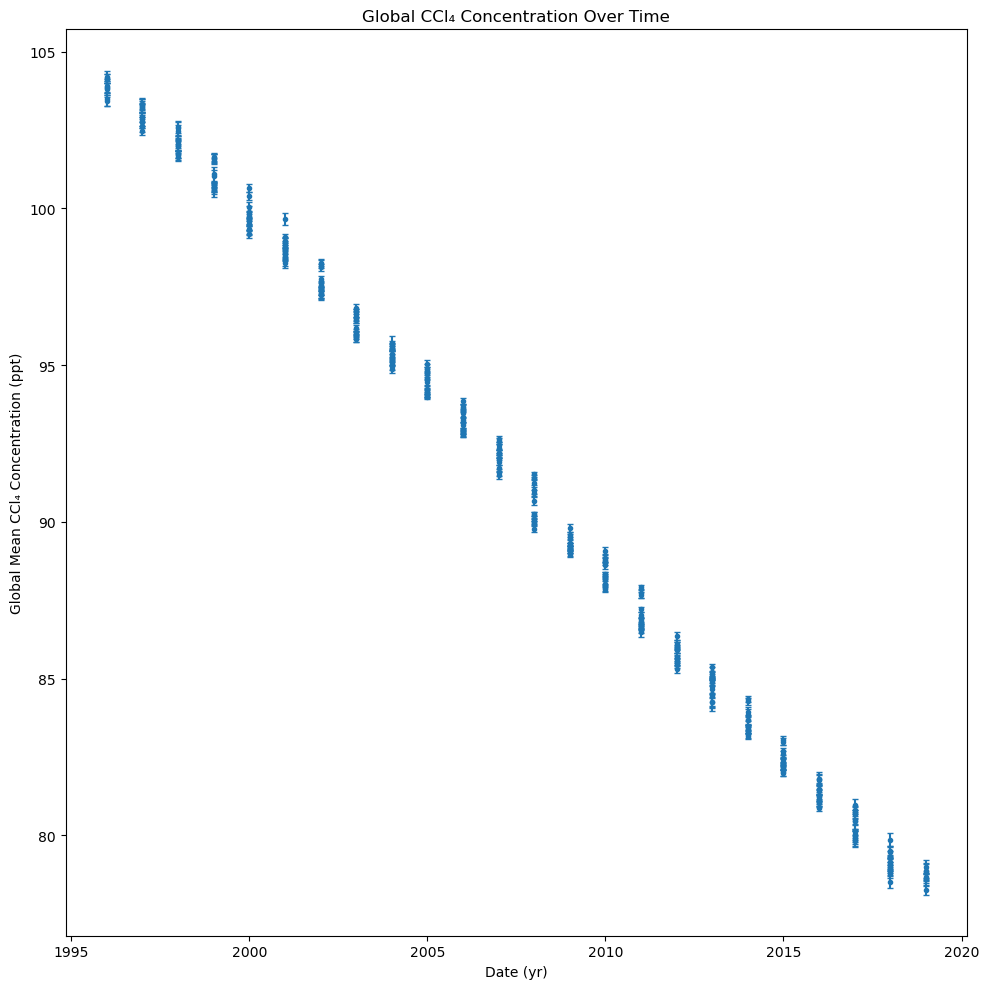

In [28]:
plt.figure(figsize=(10, 10))
plt.errorbar(
    df["date"],
    df["global_mean"],
    yerr=df["global_sd"],
    fmt="o",
    markersize=3,
    capsize=2
)

plt.xlabel("Date (yr)")
plt.ylabel("Global Mean CCl₄ Concentration (ppt)")
plt.title("Global CCl₄ Concentration Over Time")
plt.tight_layout()
plt.show()

In [29]:
x = df["date"].astype(float).values
y = df["global_mean"].values

m, b = np.polyfit(x, y, 1)
m, b

(np.float64(-1.143263549515026), np.float64(2386.3005040027065))

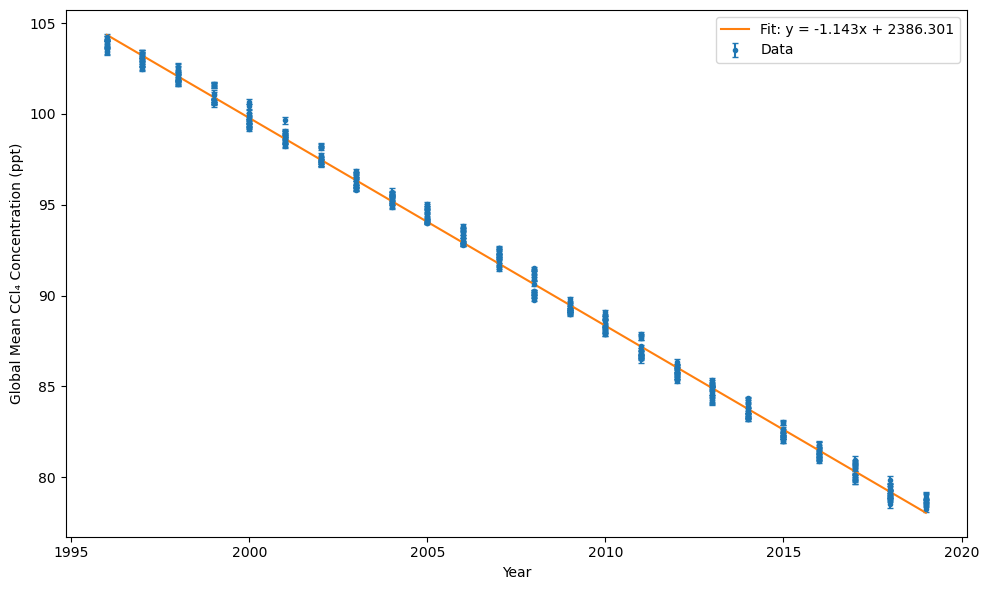

In [31]:

y_model = m * x + b

plt.figure(figsize=(10,6))
plt.errorbar(x, y, yerr=df["global_sd"], fmt="o", markersize=3, capsize=2, label="Data")
plt.plot(x, y_model, label=f"Fit: y = {m:.3f}x + {b:.3f}")

plt.xlabel("Year")
plt.ylabel("Global Mean CCl₄ Concentration (ppt)")
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
y_data = y
sigma = df["global_sd"].values
y_exp = y_model
N = len(y)

chi2 = np.sum(( (y_exp - y_data)**2 ) / (sigma**2))

chi2_reduced = chi2 / (N - 1)

print(f"Chi-square: {chi2:.4f}")
print(f"Reduced chi-square: {chi2_red:.4f}")


Chi-square: 3713.3943
Reduced chi-square: 13.3097
